**Этот ноутбук является упражнением из курса [Computer Vision](https://www.kaggle.com/learn/computer-vision). Вы можете обратиться к учебному пособию по [этой ссылке](https://www.kaggle.com/ryanholbrook/maximum-pooling).**

---


# Введение #

В этих упражнениях вы завершите извлечение признаков, начатое в Упражнении 2, исследуете, как создаётся инвариантность с помощью подвыборки по максимуму (maximum pooling), а затем рассмотрите другой вид подвыборки: *среднюю* подвыборку (average pooling).

Запустите ячейку ниже, чтобы настроить всё необходимое.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import gridspec


plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

Запустите эту ячейку, чтобы вернуться к тому месту, где вы остановились в предыдущем уроке. На этот раз мы будем использовать предопределённое ядро.

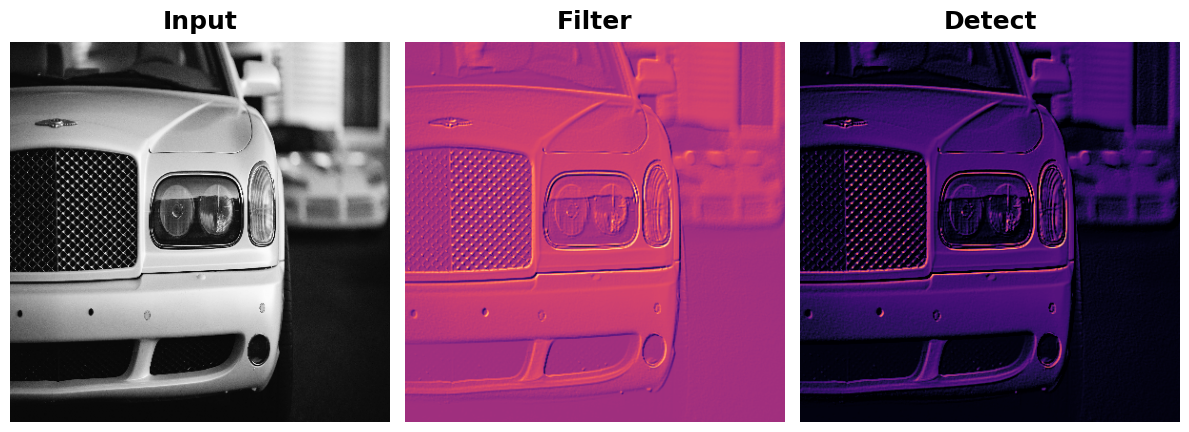

In [2]:
# Read image
image_path = 'img/car_illus.jpg'
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, size=[400, 400])

# Embossing kernel
kernel = tf.constant([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2],
])

# Reformat for batch compatibility.
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='VALID',
)

image_detect = tf.nn.relu(image_filter)

# Show what we have so far
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(tf.squeeze(image), cmap='gray')
plt.axis('off')
plt.title('Input')
plt.subplot(132)
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.title('Filter')
plt.subplot(133)
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.title('Detect')
plt.show();

# 1) Примените подвыборку для сжатия #

Для последнего шага в последовательности примените подвыборку по максимуму, используя окно подвыборки размером $2 \times 2$. Вы можете скопировать этот код для начала:

```
image_condense = tf.nn.pool(
    input=image_detect,
    window_shape=____,
    pooling_type=____,
    strides=(2, 2),
    padding='SAME',
)
```

In [3]:
# YOUR CODE HERE
image_condense = tf.nn.pool(
    input=image_detect,
    window_shape=(2, 2),
    pooling_type='MAX',
    strides=(2, 2),
    padding='SAME',
)


In [ ]:
# Lines below will give you a hint or solution code
#q_1.hint()
#q_1.solution()

Запустите следующую ячейку, чтобы увидеть, что подвыборка по максимуму сделала с признаком!

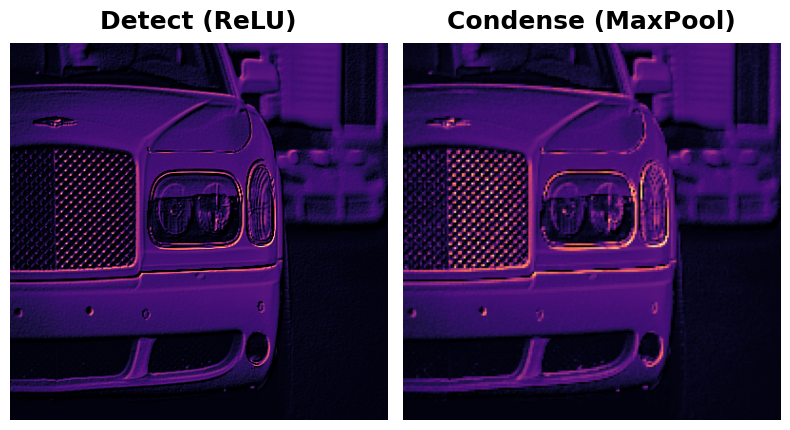

In [4]:
plt.figure(figsize=(8, 6))
plt.subplot(121)
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.title("Detect (ReLU)")
plt.subplot(122)
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.title("Condense (MaxPool)")
plt.show();

Мы узнали, как слои `MaxPool2D` придают свёрточной сети свойство **трансляционной инвариантности** на небольших расстояниях. В этом упражнении у вас будет возможность понаблюдать за этим в действии.

Следующая ячейка кода будет случайным образом применять небольшой сдвиг к кругу, а затем несколько раз сжимать изображение с помощью подвыборки по максимуму. Запустите ячейку один раз и обратите внимание на изображение, которое получается в результате.

In [5]:
REPEATS = 4
SIZE = [64, 64]

# Create a randomly shifted circle
image = visiontools.circle(SIZE, r_shrink=4, val=1)
image = tf.expand_dims(image, axis=-1)
image = visiontools.random_transform(image, jitter=3, fill_method='replicate')
image = tf.squeeze(image)

plt.figure(figsize=(16, 4))
plt.subplot(1, REPEATS+1, 1)
plt.imshow(image, vmin=0, vmax=1)
plt.title("Original\nShape: {}x{}".format(image.shape[0], image.shape[1]))
plt.axis('off')

# Now condense with maximum pooling several times
for i in range(REPEATS):
    ax = plt.subplot(1, REPEATS+1, i+2)
    image = tf.reshape(image, [1, *image.shape, 1])
    image = tf.nn.max_pool(image, 2, 2, padding='SAME')
    image = tf.squeeze(image)
    plt.imshow(image, vmin=0, vmax=1)
    plt.title("MaxPool\nShape: {}x{}".format(image.shape[0], image.shape[1]))
    plt.axis('off')

plt.tight_layout()
plt.show();

NameError: name 'visiontools' is not defined

# 2) Исследуйте инвариантность #

Предположим, вы запустили ячейку выше несколько раз, каждый раз получая случайный сдвиг. Что вы заметили в отношении изображения после применения подвыборки по максимуму? Заполните текстовую ячейку ниже своими наблюдениями.



Решение. В обучающем руководстве мы говорили о том, что максимальный пулинг обеспечивает инвариантность к сдвигу на небольшие расстояния. Это означает, что после многократного применения максимального пулинга небольшие сдвиги должны исчезать. Если запустить ячейку несколько раз, можно увидеть, что результат всегда один и тот же: операция пулинга уничтожает эти небольшие сдвиги.

## Глобальная средняя подвыборка #

Вместо того чтобы брать максимальное значение в окне (подвыборка по максимуму), мы также можем взять среднее (средняя подвыборка). Этот вид подвыборки часто используется в классификационной головке (classification head) свёрточной сети.
```
model = keras.Sequential([
    pretrained_base,
    layers.GlobalAvgPool2D(),
    layers.Dense(1, activation='sigmoid'),
])
```
На практике глобальная средняя подвыборка (`GlobalAvgPool2D`) используется чаще, чем `MaxPool2D`. Она работает аналогично, но с одним отличием: вместо того, чтобы брать максимум по окну, она берёт среднее по окну. А при использовании `GlobalAvgPool2D` окно охватывает весь тензор, сводя каждый канал к одному значению.

Визуализируем это. В следующей ячейке мы возьмём карты признаков из предыдущего упражнения и применим к ним глобальную среднюю подвыборку.

In [ ]:
feature_maps = [visiontools.random_map(
    [5, 5], scale=0.1, decay_power=4) for _ in range(8)]

gs = gridspec.GridSpec(1, 8, wspace=0.01, hspace=0.01)
plt.figure(figsize=(18, 2))
for i, feature_map in enumerate(feature_maps):
    plt.subplot(gs[i])
    plt.imshow(feature_map, vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle('Feature Maps', size=18, weight='bold', y=1.1)
plt.show()

# reformat for TensorFlow
feature_maps_tf = [tf.reshape(feature_map, [1, *feature_map.shape, 1])
                   for feature_map in feature_maps]

global_avg_pool = tf.keras.layers.GlobalAvgPool2D()
pooled_maps = [global_avg_pool(feature_map) for feature_map in feature_maps_tf]
img = np.array(pooled_maps)[:, :, 0].T

plt.imshow(img, vmin=0, vmax=1)
plt.axis('off')
plt.title('Pooled Feature Maps')
plt.show()

Поскольку каждая карта признаков размером $5 \times 5$ была уменьшена до одного значения, глобальная подвыборка сократила количество параметров, необходимых для представления этих признаков, в 25 раз — существенная экономия!

Теперь перейдём к пониманию подвыборочных признаков.

После того как мы свели признаки к одному значению, остаётся ли у головки достаточно информации для определения класса? Эта часть упражнения исследует данный вопрос.

Давайте пропустим несколько изображений из нашего набора данных *Car or Truck* через VGG16 и изучим признаки, полученные после подвыборки. Сначала запустите эту ячейку, чтобы определить модель и загрузить набор данных.

In [7]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load VGG16
pretrained_base = tf.keras.models.load_model(
    './data/cv-course-models/vgg16-pretrained-base',
)

model = keras.Sequential([
    pretrained_base,
    # Attach a global average pooling layer after the base
    layers.GlobalAvgPool2D(),
])

# Load dataset
ds = image_dataset_from_directory(
    './data/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=1,
    shuffle=True,
)

ds_iter = iter(ds)

Found 5117 files belonging to 2 classes.


Обратите внимание, как мы добавили слой `GlobalAvgPool2D` после предобученной базы VGG16. Обычно VGG16 создаёт 512 карт признаков для каждого изображения. Слой `GlobalAvgPool2D` сводит каждую из них к одному значению, своего рода «среднему пикселю».

Следующая ячейка пропустит изображение из набора данных *Car or Truck* через VGG16 и покажет вам 512 средних пикселей, созданных `GlobalAvgPool2D`. Запустите ячейку несколько раз и понаблюдайте за пикселями, которые создают изображения автомобилей, по сравнению с пикселями от грузовиков.

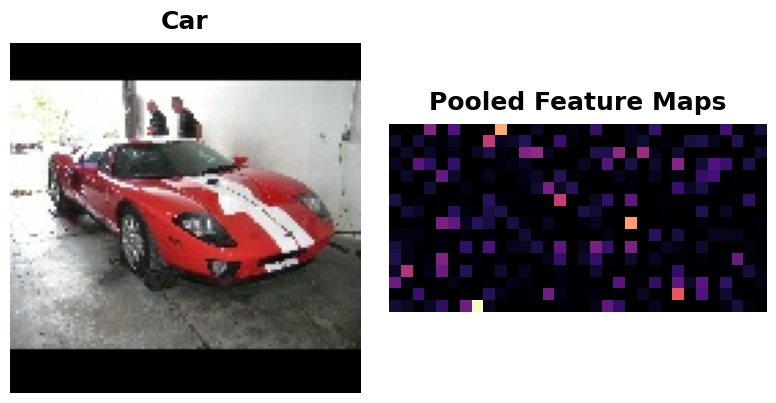

In [11]:
car = next(ds_iter)

car_tf = tf.image.resize(car[0], size=[128, 128])
car_features = model(car_tf)
car_features = tf.reshape(car_features, shape=(16, 32))
label = int(tf.squeeze(car[1]).numpy())

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(tf.squeeze(car[0]))
plt.axis('off')
plt.title(["Car", "Truck"][label])
plt.subplot(122)
plt.imshow(car_features)
plt.title('Pooled Feature Maps')
plt.axis('off')
plt.show();

# 3) Поймите подвыборочные признаки #

Что вы видите? Достаточно ли различны подвыборочные признаки для автомобилей и грузовиков, чтобы их можно было различить? Как бы вы интерпретировали эти подвыборочные значения? Как это может помочь классификации? После того как вы обдумаете это, запустите следующую ячейку для ответа. (Или сначала посмотрите подсказку!)

Правильно:

 Базовая модель VGG16 генерирует 512 карт признаков. Можно представить, что каждая карта признаков представляет собой какой-то высокоуровневый визуальный элемент исходного изображения — например, колесо или окно. Объединение карт в пул дает нам одно число, которое можно рассматривать как оценку наличия этого элемента: большое число, если элемент присутствует, и маленькое, если его нет. Автомобили, как правило, получают высокие оценки по одному набору признаков, а грузовики — по другому. Теперь вместо того, чтобы пытаться сопоставить исходные признаки с классами, нейросеть должна работать только с оценками, полученными с помощью GlobalAvgPool2D. Это гораздо более простая задача.

Подсказка: VGG16 создает 512 карт признаков на основе изображения, на котором может быть изображено что-то вроде колеса или окна. Каждый квадрат на объединенных картах признаков представляет собой отдельный признак. Что означает большое значение для того или иного признака?



Глобальная средняя подвыборка часто используется в современных свёрточных сетях. Одно из главных преимуществ — она значительно сокращает количество параметров в модели, при этом всё ещё сообщая, присутствует ли некоторый признак на изображении или нет — а для классификации этого обычно достаточно. Если вы создаёте свёрточный классификатор, стоит попробовать!

# Заключение #

В этом уроке мы исследовали последнюю операцию в процессе извлечения признаков: **сжатие** с помощью **подвыборки по максимуму**. Подвыборка — одна из ключевых особенностей свёрточных сетей, которая обеспечивает некоторые из их характерных преимуществ: эффективность работы с визуальными данными, уменьшенный размер параметров по сравнению с полносвязными сетями, трансляционная инвариантность. Мы увидели, что она используется не только в базе при извлечении признаков, но также может применяться в головке при классификации. Понимание этого необходимо для полного понимания свёрточных сетей.

# Продолжайте обучение #

На следующем уроке мы завершим обсуждение операций извлечения признаков, рассмотрев **скользящие окна** — типичный способ описания того, как операции свёртки и подвыборки сканируют изображение. Мы опишем два последних параметра в слоях `Conv2D` и `MaxPool2D`: `strides` и `padding`. [**Переходите к уроку**](https://www.kaggle.com/ryanholbrook/the-sliding-window) прямо сейчас!

---




*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/computer-vision/discussion), чтобы пообщаться с другими учащимися.*